# **PROYECTO: INTRODUCCIÓN AL APRENDIZAJE AUTOMÁTICO**

Una vez visto el ***Módulo 5: Introducción al Aprendizaje Automático***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **proyecto integrador**. En este proyecto se verá todo lo aprendido durante el **master en data science**.

Por lo que, el procedimiento a resolver es libre mientras se cumplan los puntos solicitados dentro de la descripción.

Puede descargar el conjunto de datos desde [aquí](https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/edit?usp=drive_link).

## **ANÁLISIS DE TAMAÑO DE MERCADO DE VEHÍCULOS ELÉCTRICOS**

El análisis del tamaño del mercado es un aspecto crucial de la investigación de mercado que determina el volumen potencial de ventas dentro de un mercado determinado. Ayuda a las empresas a comprender la magnitud de la demanda, evaluar los niveles de saturación del mercado e identificar oportunidades de crecimiento. En este proyecto, Iicill lo llevará a través de la tarea de análisis de tamaño de mercado de Vehículos Eléctricos usando Python.

El análisis de tamaño de mercado para vehículos eléctricos implica un proceso de varios pasos que incluye definir el alcance del mercado, recopilar y preparar datos, modelar analíticamente y comunicar los hallazgos a través de visualización e informes. A continuación se muestra el proceso que puede seguir para la tarea de análisis de tamaño de mercado de vehículos eléctricos:

1.   Definir si el análisis es global, regional o centrado en países específicos.

2.   Recopilar información de asociaciones de la industria, empresas de investigación de mercado (por ejemplo, BloombergNEF, AIE) y publicaciones gubernamentales relevantes para el mercado de EV*.

3.   Utilice datos históricos para identificar tendencias en ventas, producción y mercado de EV*.

4.   Analice el tamaño del mercado y las tasas de crecimiento para diferentes segmentos de EV*.

5.   Según el análisis del tamaño del mercado, proporcione recomendaciones estratégicas para las empresas que buscan ingresar o expandirse en el mercado de EV* a través de predicciones.

_*NOTA: EV significa Electric Vehicles_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

%matplotlib inline

In [26]:
# Importar dataset
ruta_colab = '/content/Electric_Vehicle_Population_Data.xlsx - Electric_Vehicle_Population_Dat.csv'
df = pd.read_csv(ruta_colab)

df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177861,7SAYGDEE3N,Pierce,Bonney Lake,WA,98391.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,31.0,195224452,POINT (-122.183805 47.18062),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
177862,KM8K23AG1P,Mason,Shelton,WA,98584.0,2023,HYUNDAI,KONA ELECTRIC,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,35.0,228454180,POINT (-123.105305 47.211085),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.304596e+10
177863,5YJYGDEE6M,Grant,Quincy,WA,98848.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,13.0,168797219,POINT (-119.8493873 47.2339933),PUD NO 2 OF GRANT COUNTY,5.302501e+10
177864,WVGKMPE27M,King,Black Diamond,WA,98010.0,2021,VOLKSWAGEN,ID.4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,5.0,182448801,POINT (-122.00451 47.312185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [27]:
# Ver tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

In [9]:
# Detección de duplicados y valores nulos por columna
if df.duplicated().sum() > 0:
    print(f"Hay {df.duplicated().sum()} registros duplicados.")
else:
    print("No hay registros duplicados.")

No hay registros duplicados.


In [28]:
print(df.isnull().sum())

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       9
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64


In [29]:
# Verificar valores nulos por columnas de texto
df[['Legislative District','County', 'Postal Code','Vehicle Location', 'Electric Utility','Electric Utility','2020 Census Tract']].isnull().sum()

,0
Legislative District,389
County,5
Postal Code,5
Vehicle Location,9
Electric Utility,5
Electric Utility,5
2020 Census Tract,5


In [30]:
# Visualizar los primeros 10 registros nulos
df[df.isnull().any(axis=1)].head(10)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
57115,1G1FZ6S00K,Washoe,Reno,NV,89521.0,2019,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,NaN,231094930,POINT (-119.74505 39.436555),NON WASHINGTON STATE ELECTRIC UTILITY,3.203100e+10
75427,5YJSA1E54P,District of Columbia,Washington,DC,20003.0,2023,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,238713044,POINT (-76.985835 38.88411),NON WASHINGTON STATE ELECTRIC UTILITY,1.100101e+10
78159,3FA6P0PU8F,Kern,Ridgecrest,CA,93555.0,2015,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,NaN,475775205,POINT (-117.67228 35.62073),NON WASHINGTON STATE ELECTRIC UTILITY,6.029005e+09
79645,5UXKT0C36H,Cumberland,Fayetteville,NC,28305.0,2017,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14,0,NaN,110287313,POINT (-78.90195 35.058245),NON WASHINGTON STATE ELECTRIC UTILITY,3.705100e+10
79711,2C4RC1H78J,Oldham,Goshen,KY,40026.0,2018,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,33,0,NaN,277234681,POINT (-85.5824778 38.4053653),NON WASHINGTON STATE ELECTRIC UTILITY,2.118503e+10
84573,WA1AAAGE3P,Orange,Buena Park,CA,90621.0,2023,AUDI,E-TRON,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,224666711,POINT (-117.997795 33.86741),NON WASHINGTON STATE ELECTRIC UTILITY,6.059111e+09
85326,7JRH60FL6R,Cumberland,Carlisle,PA,17013.0,2024,VOLVO,S60,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,41,0,NaN,257767044,POINT (-77.19078 40.202425),NON WASHINGTON STATE ELECTRIC UTILITY,4.204101e+10
86110,7SAYGDEE8N,Stafford,Stafford,VA,22554.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,223816197,POINT (-77.410205 38.42543),NON WASHINGTON STATE ELECTRIC UTILITY,5.117901e+10
87815,3FMTK1SS4P,Montgomery,Kensington,MD,20895.0,2023,FORD,MUSTANG MACH-E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,239901049,POINT (-77.073155 39.028465),NON WASHINGTON STATE ELECTRIC UTILITY,2.403170e+10
88395,5YJ3E1EB4N,York,Yorktown,VA,23693.0,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,185350084,POINT (-76.456505 37.11771),NON WASHINGTON STATE ELECTRIC UTILITY,5.119905e+10


In [33]:

df['County'] = df['County'].fillna('Unidentified Country')
df['City'] = df['City'].fillna('Unidentified City')
df['Electric Utility'] = df['Electric Utility'].fillna('Unidentified Electric Utility')
df['Vehicle Location'] = df['Vehicle Location'].fillna('Unidentified Vehicle Location')

print(df.isnull().sum())

VIN (1-10)                                             0
County                                                 0
City                                                   0
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       0
Electric Utility                                       0
2020 Census Tract                                      5
dtype: int64


In [35]:
# Verificar valores nulos por columna numérica
columnas_numericas = ['Legislative District', 'Postal Code','2020 Census Tract']
print(df[columnas_numericas].isnull().sum())

Legislative District    389
Postal Code               5
2020 Census Tract         5
dtype: int64


In [48]:
df = df.dropna(subset=['Make', 'Model'])
df['Electric Range'] = df['Electric Range'].fillna(df['Electric Range'].median())

# 4. Normalización y Formato
# Convertir años a entero
df['Model Year'] = df['Model Year'].astype(int)

# Normalizar nombres de fabricantes a mayúsculas para evitar 'Tesla' vs 'TESLA'
df['Make'] = df['Make'].str.upper().str.strip()

# 5. Detección de anomalías
# Un valor de rango 0 en un vehículo eléctrico puro (BEV) puede ser un error.
# Vamos a crear una copia limpia para trabajar
df_limpio = df[df['Electric Range'] >= 0]

print("\nLimpieza completada. Dimensiones del nuevo dataset:", df_limpio.shape)


Limpieza completada. Dimensiones del nuevo dataset: (177866, 17)


In [50]:
print(df.isnull().sum())

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64


In [53]:
df.dtypes

,0
VIN (1-10),object
County,object
City,object
State,object
Postal Code,float64
Model Year,int64
Make,object
Model,object
Electric Vehicle Type,object
Clean Alternative Fuel Vehicle (CAFV) Eligibility,object


In [54]:
df.head(1)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


In [86]:
df['Make'] = df['Make'].astype('category')
df['Model'] = df['Model'].astype('category')
df['County'] = df['County'].astype('category')
df['City'] = df['City'].astype('category')
df['Electric Vehicle Type'] = df['Electric Vehicle Type'].astype('category')
df.dtypes

,0
VIN (1-10),object
County,category
City,category
State,object
Postal Code,float64
Model Year,int64
Make,category
Model,category
Electric Vehicle Type,category
Clean Alternative Fuel Vehicle (CAFV) Eligibility,object


# EDA

In [61]:
# Definición de las columnas numéricas relevantes
columnas_numericas = ['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District']

# Análisis descriptivo básico
df_limpio[columnas_numericas].describe()

,Model Year,Electric Range,Base MSRP,Legislative District
count,177866.000000,177866.000000,177866.000000,177866.000000
mean,2020.515512,58.842162,1073.109363,29.135951
std,2.989384,91.981298,8358.624956,14.876975
min,1997.000000,0.000000,0.000000,1.000000
25%,2019.000000,0.000000,0.000000,18.000000
50%,2022.000000,0.000000,0.000000,33.000000
75%,2023.000000,75.000000,0.000000,42.000000
max,2024.000000,337.000000,845000.000000,49.000000


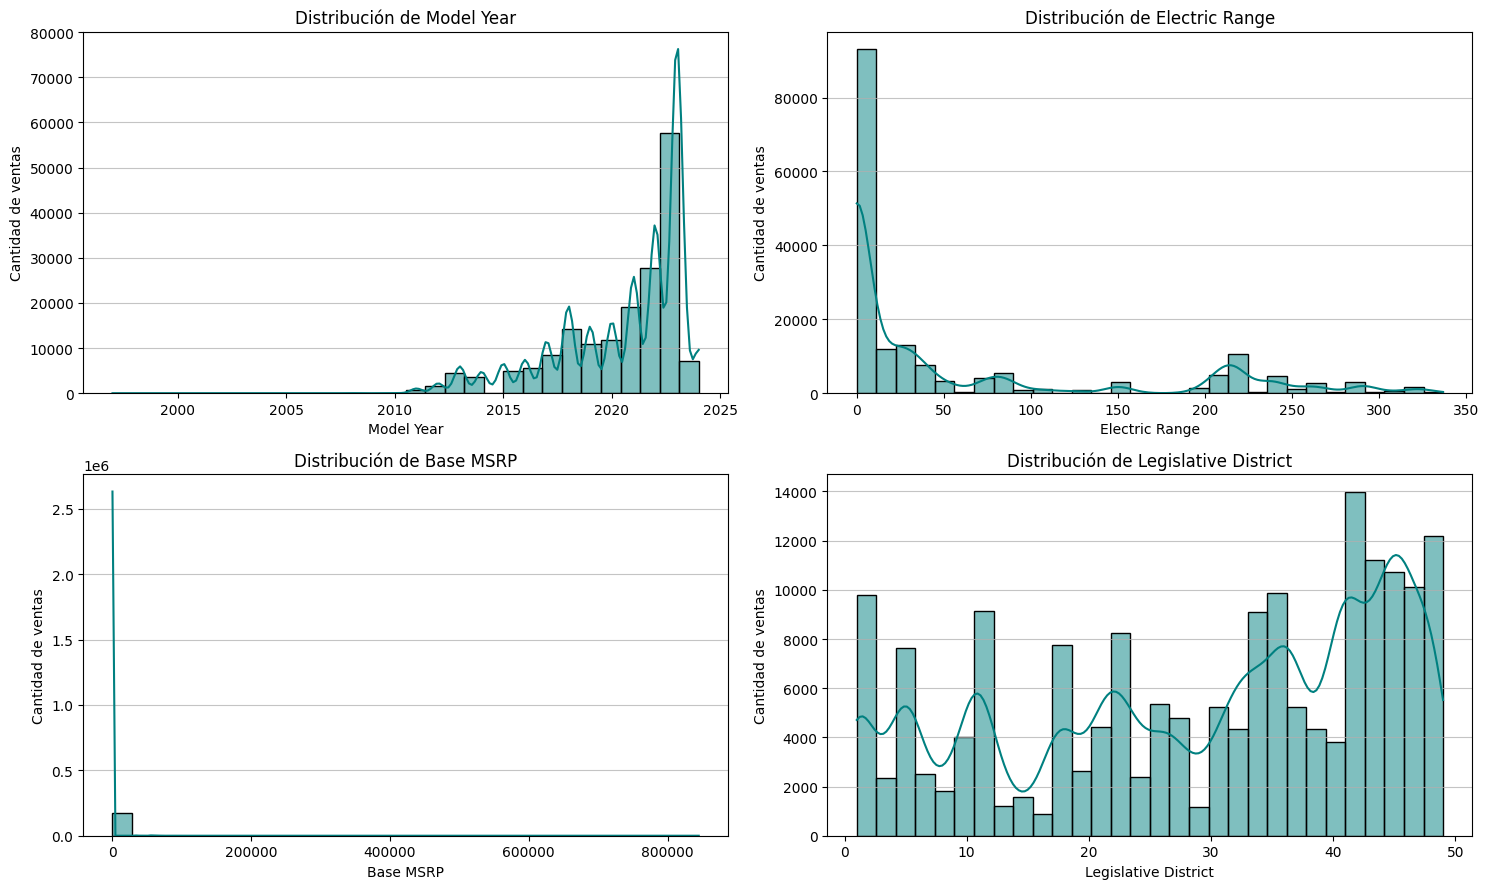

In [65]:
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.xlabel(col)
    plt.ylabel('Cantidad de ventas')
    plt.title(f'Distribución de {col}')
    plt.grid(axis= 'y', alpha = 0.75 )

plt.tight_layout()
plt.show()

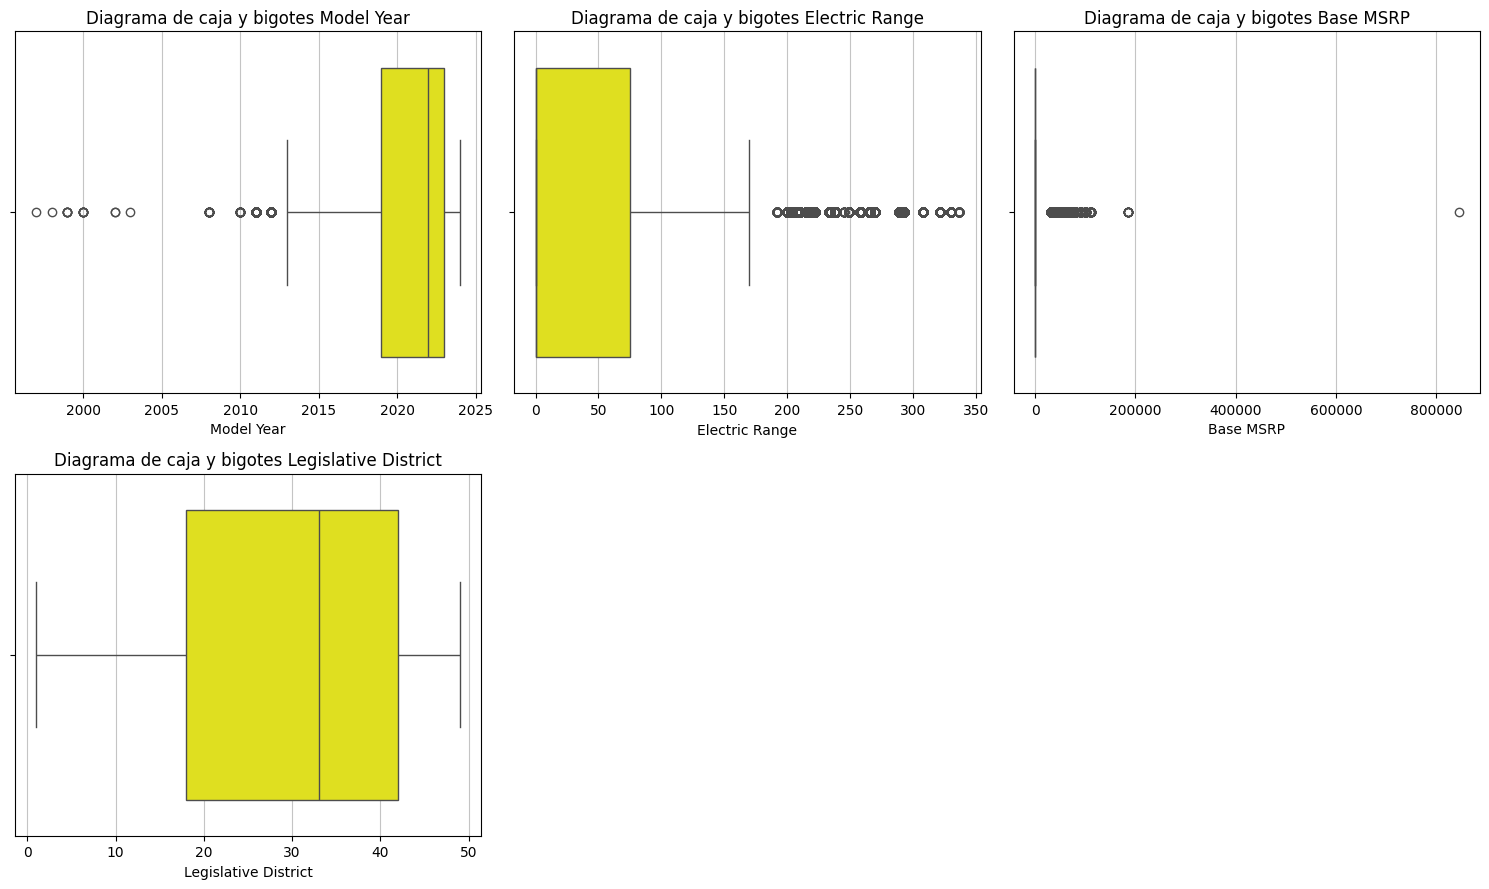

In [74]:
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.boxplot(x=df[col], color = 'yellow')
  plt.xlabel(col)
  plt.ylabel('')
  plt.title(f'Diagrama de caja y bigotes {col}')
  plt.grid(axis= 'x', alpha = 0.75 )

plt.tight_layout()
plt.show()

In [67]:
# Ver cantidad de registros iniciales
print(f'Cantidad de datos iniciales: {len(df)}')

Cantidad de datos iniciales: 177866


Cantidad de datos con outliers eliminados en Model Year: 2453
Cantidad de datos con outliers eliminados en Electric Range: 30975
Cantidad de datos con outliers eliminados en Base MSRP: 1783
Cantidad de datos con outliers eliminados en Legislative District: 0


<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

<Figure size 1500x900 with 0 Axes>

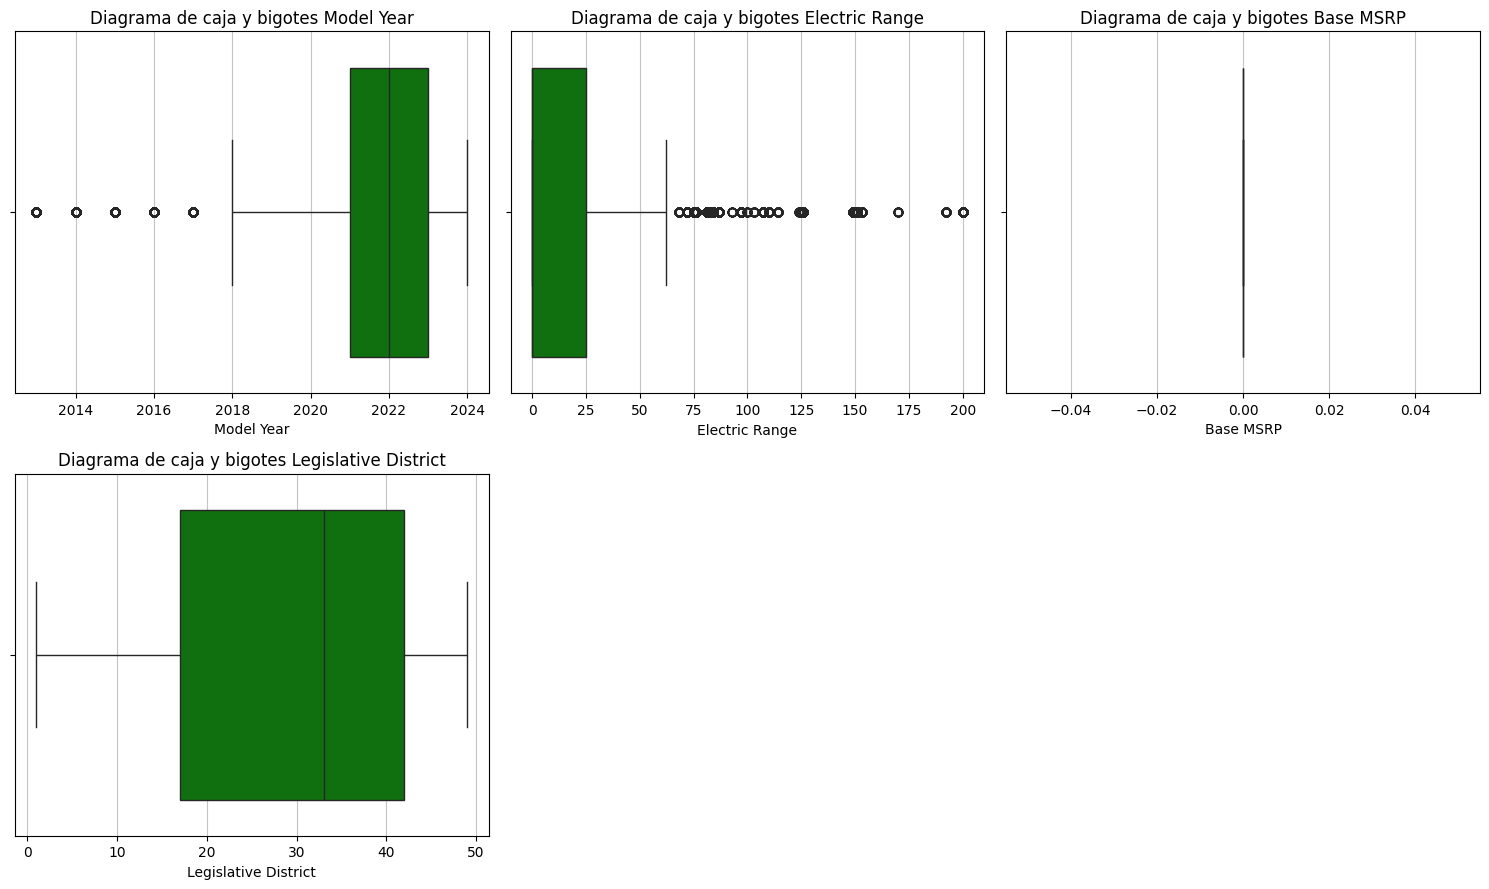

In [73]:
# Calculo del IQR
df_copy = df.copy()

for col in columnas_numericas:
  Q1 = df_copy[col].quantile(0.25)
  Q3 = df_copy[col].quantile(0.75)
  IQR = Q3 - Q1

  lim_inf_iqr = Q1 - 1.5 * IQR
  lim_sup_iqr = Q3 + 1.5 * IQR

  cant_inicial = len(df_copy)
  df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
  cant_final = len(df_copy)
  print(f'Cantidad de datos con outliers eliminados en {col}: {cant_inicial - cant_final}')

  plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1): #i = index se refiere
  plt.subplot(2, 3, i)
  sns.boxplot(x=df_copy[col], color = 'green')
  plt.xlabel(col)
  plt.ylabel('')
  plt.title(f'Diagrama de caja y bigotes {col}')
  plt.grid(axis= 'x', alpha = 0.75 )

plt.tight_layout()
plt.show()

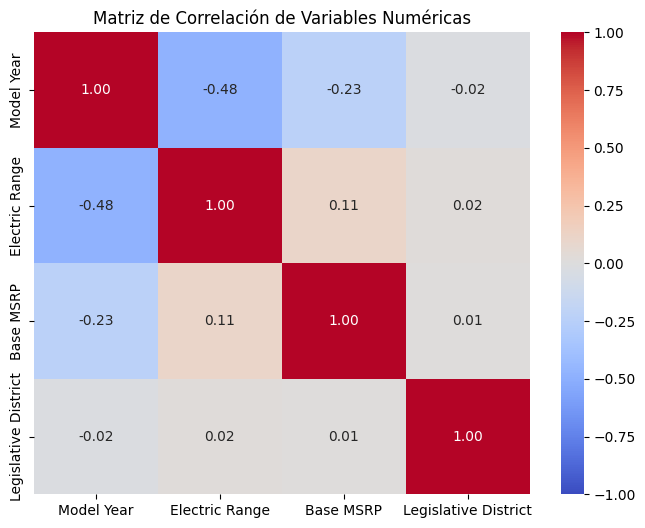

In [75]:

matriz_corr = df[columnas_numericas].corr(numeric_only=True)


plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

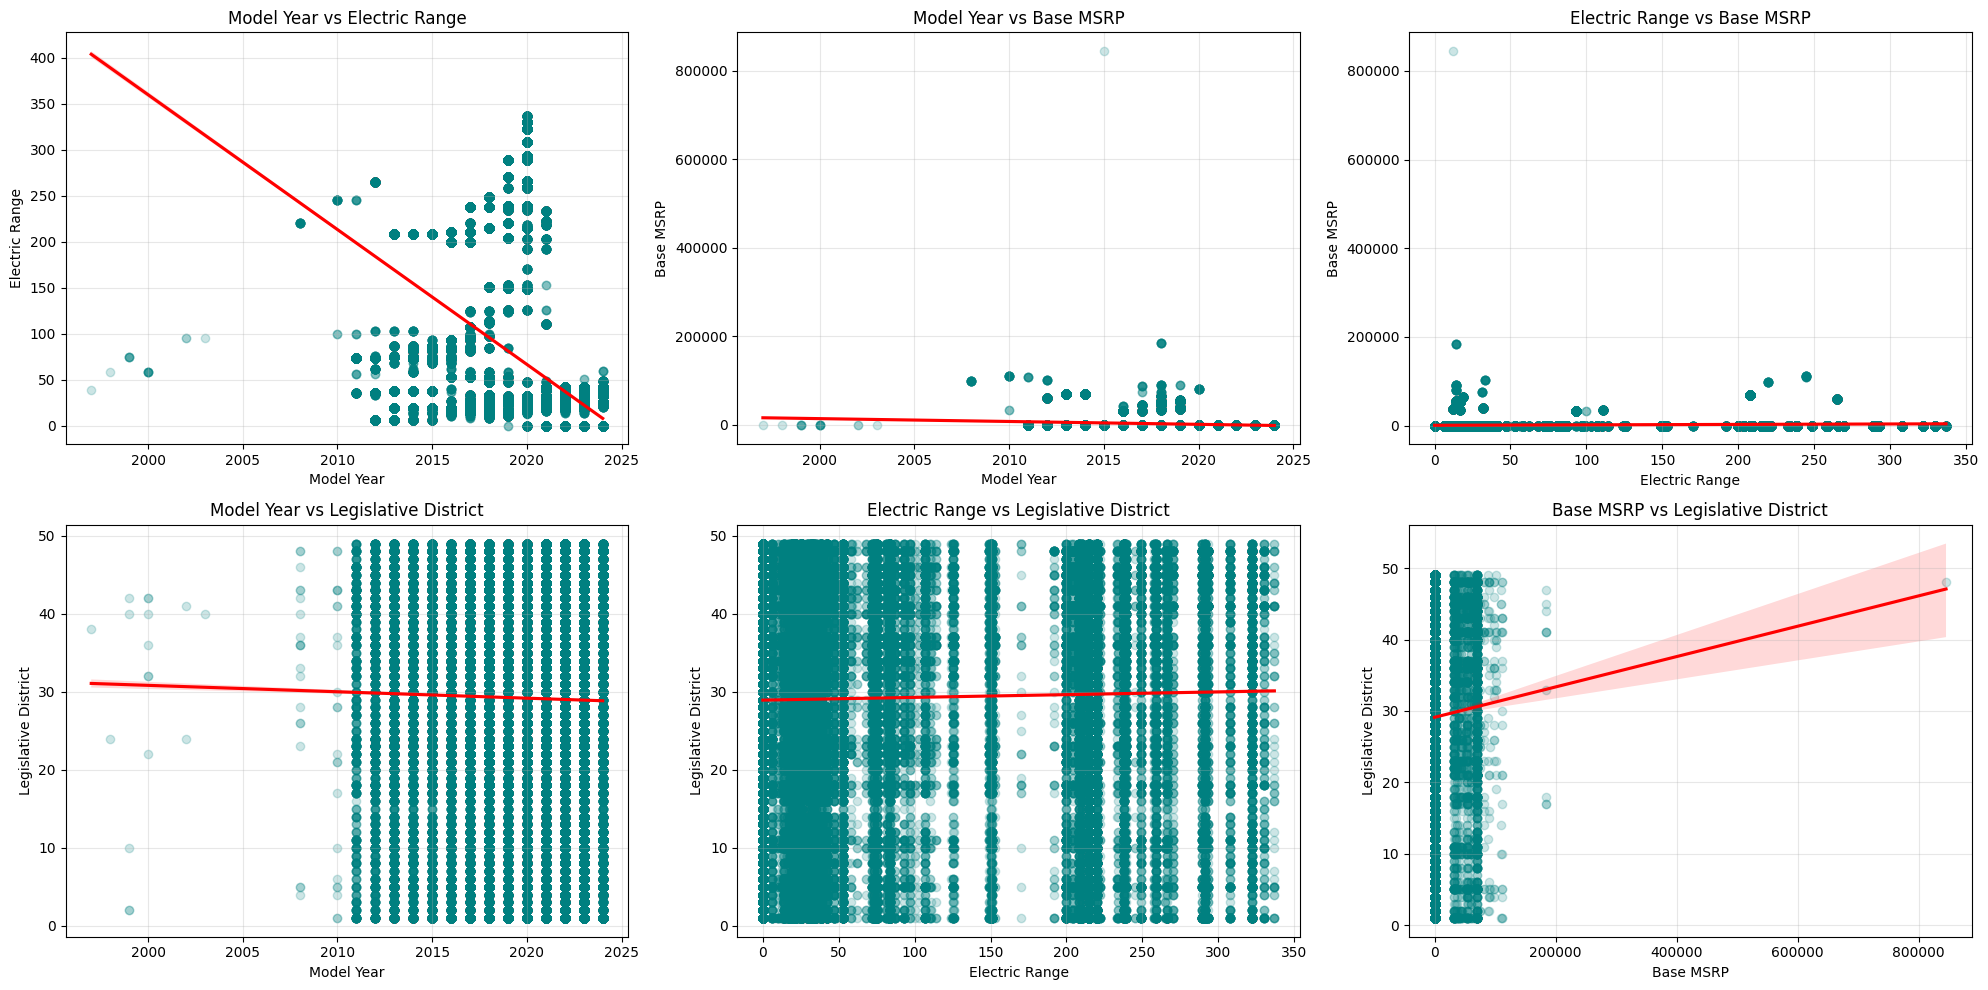

In [77]:
cols_a_comparar = ['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()


comparaciones = [
    ('Model Year', 'Electric Range'),
    ('Model Year', 'Base MSRP'),
    ('Electric Range', 'Base MSRP'),
    ('Model Year', 'Legislative District'),
    ('Electric Range', 'Legislative District'),
    ('Base MSRP', 'Legislative District')
]


for i, (col_x, col_y) in enumerate(comparaciones):
    data_filtrada = df.dropna(subset=[col_x, col_y])

    sns.regplot(ax=axes[i], data=data_filtrada, x=col_x, y=col_y,
                scatter_kws={'alpha':0.2, 'color':'teal'},
                line_kws={'color':'red'})

    axes[i].set_title(f'{col_x} vs {col_y}')
    axes[i].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Visualización

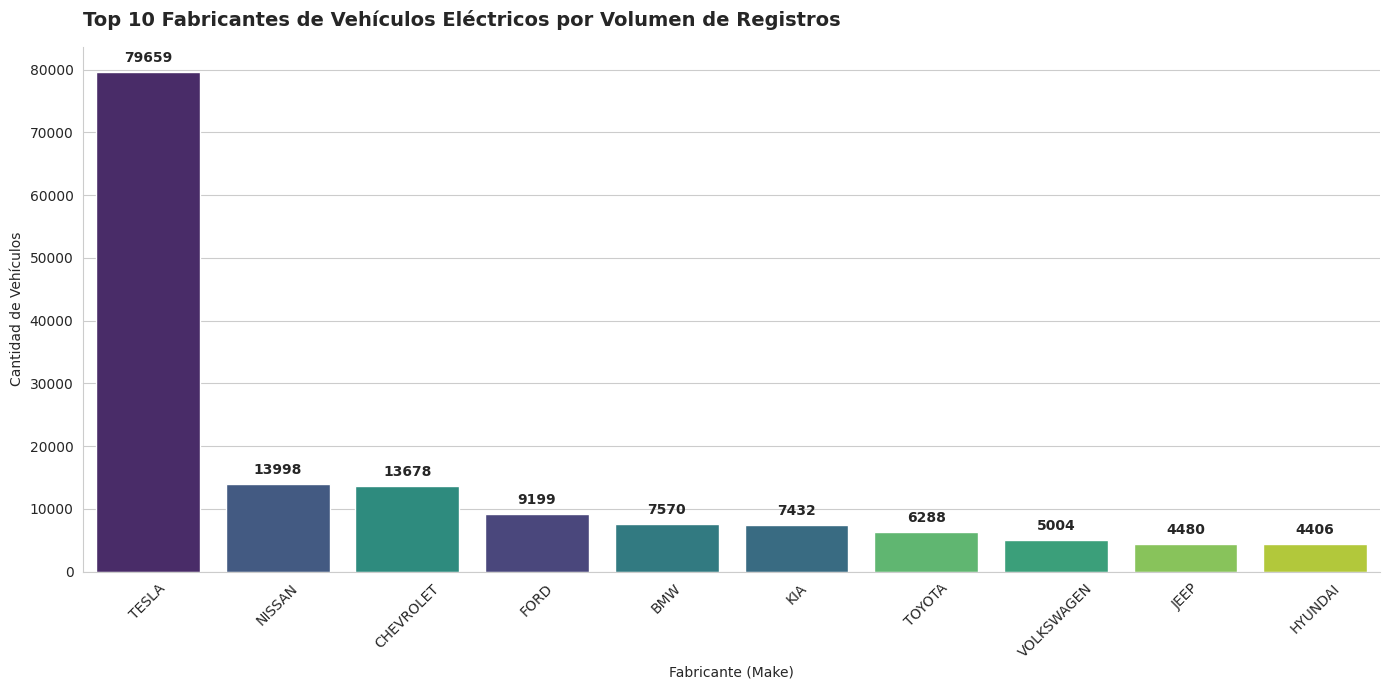

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Ordenamos por las 10 marcas con más registros para que el gráfico no esté saturado
top_10_marcas = df_limpio['Make'].value_counts().nlargest(10).index

ax = sns.countplot(
    data=df_limpio[df_limpio['Make'].isin(top_10_marcas)],
    x='Make',
    order=top_10_marcas,
    palette='viridis',
    hue='Make',
    legend=False
)

# Añadir etiquetas de cantidad sobre las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 5), textcoords='offset points'
        )

plt.title('Top 10 Fabricantes de Vehículos Eléctricos por Volumen de Registros', loc='left', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fabricante (Make)')
plt.ylabel('Cantidad de Vehículos')
plt.xticks(rotation=45) # Rotamos etiquetas si el nombre del fabricante es largo
sns.despine()
plt.tight_layout()
plt.show()

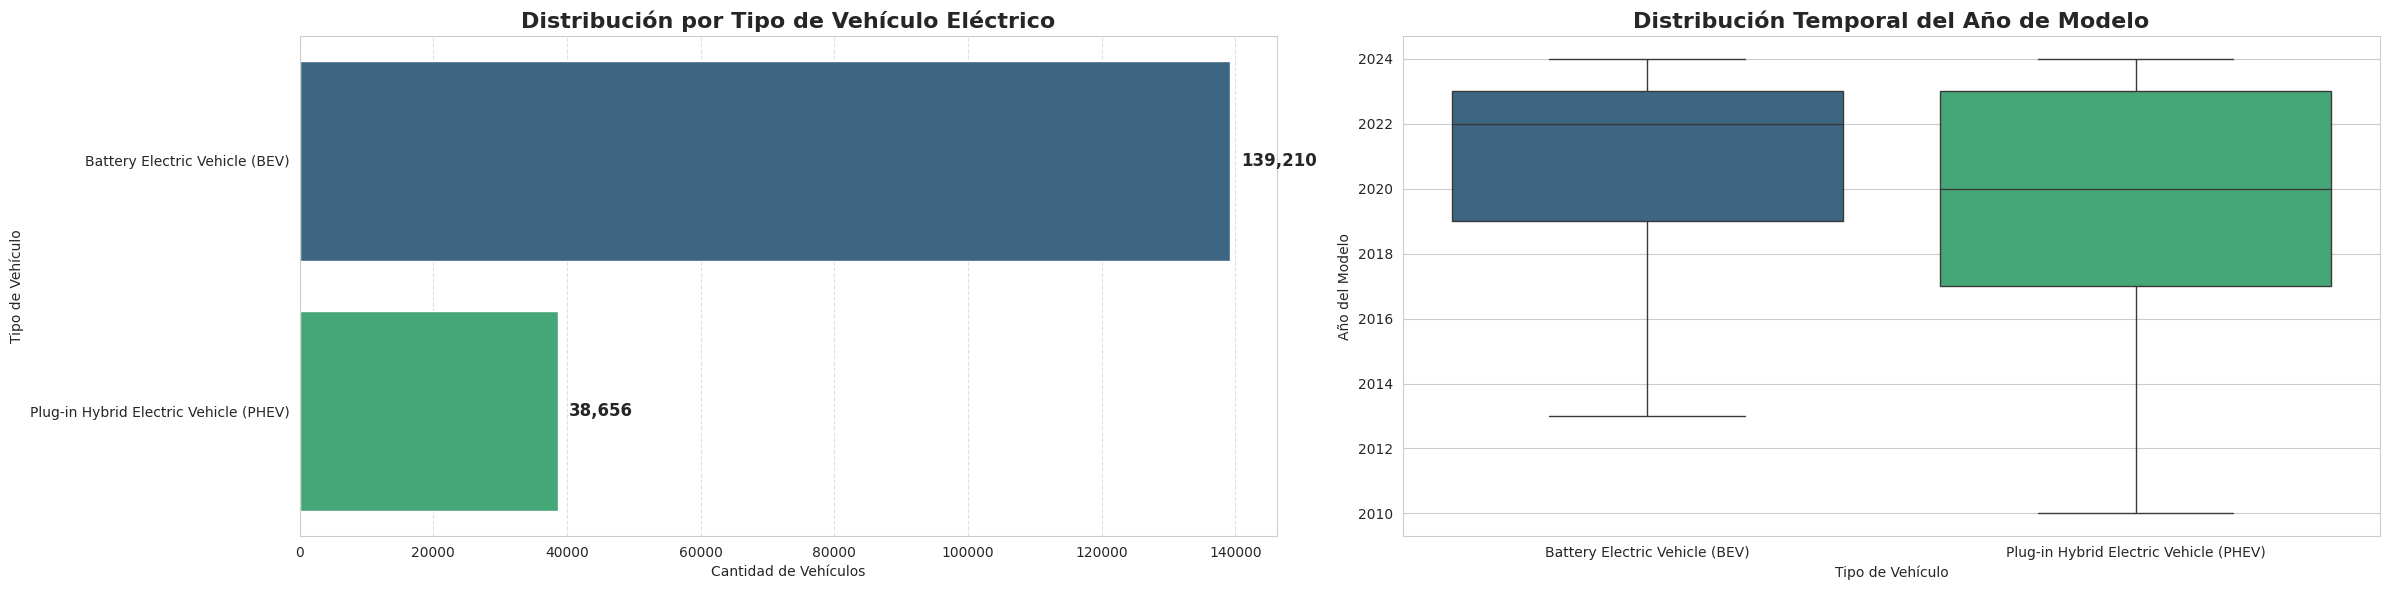

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(24, 6))

# 1. Gráfico de Barras: Distribución de tipos de vehículos (BEV vs PHEV)
ax = plt.subplot(1, 2, 1)
orden = df_limpio['Electric Vehicle Type'].value_counts().index
sns.countplot(data=df_limpio, y='Electric Vehicle Type', order=orden,
              palette='viridis', hue='Electric Vehicle Type', legend=False)

# Añadir etiquetas de texto a las barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,}',
            (width, p.get_y() + p.get_height() / 2),
            ha='left', va='center',
            fontsize=12, fontweight='bold',
            xytext=(8, 0), textcoords='offset points'
        )
plt.title('Distribución por Tipo de Vehículo Eléctrico', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de Vehículos')
plt.ylabel('Tipo de Vehículo')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 2. Boxplot: Año de modelo por tipo de vehículo
plt.subplot(1, 2, 2)
sns.boxplot(data=df_limpio, x='Electric Vehicle Type', y='Model Year',
            palette='viridis', hue='Electric Vehicle Type', legend=False, showfliers=False)

plt.title('Distribución Temporal del Año de Modelo', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Año del Modelo')

plt.tight_layout()
plt.show()

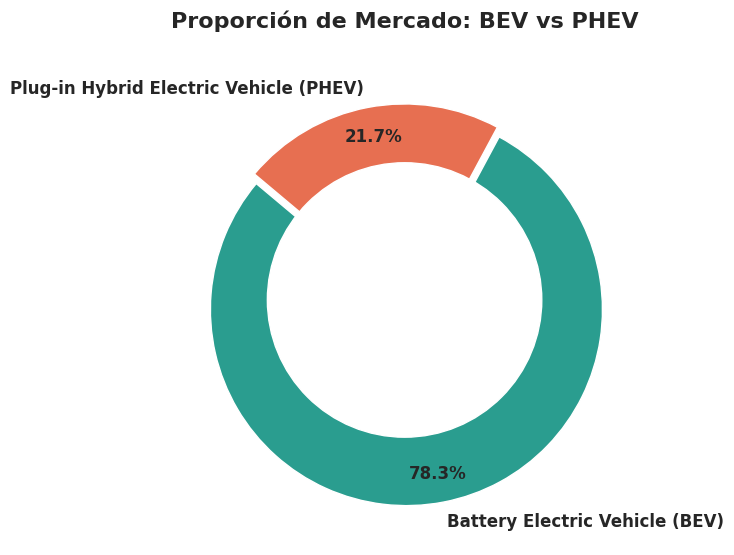

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos
# Filtramos para asegurarnos de que solo tenemos los tipos principales
pie_data = df_limpio['Electric Vehicle Type'].value_counts()

# 2. Configuración estética
colors_pie = ["#2A9D8F", "#E76F51"] # Colores modernos para contrastar BEV y PHEV
explode_val = 0.05

# 3. Crear el gráfico de dona
plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_pie,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.85,
    explode=(explode_val, 0) # Resalta la categoría mayor
)

# 4. Crear el agujero central para estilo "dona"
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción de Mercado: BEV vs PHEV', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

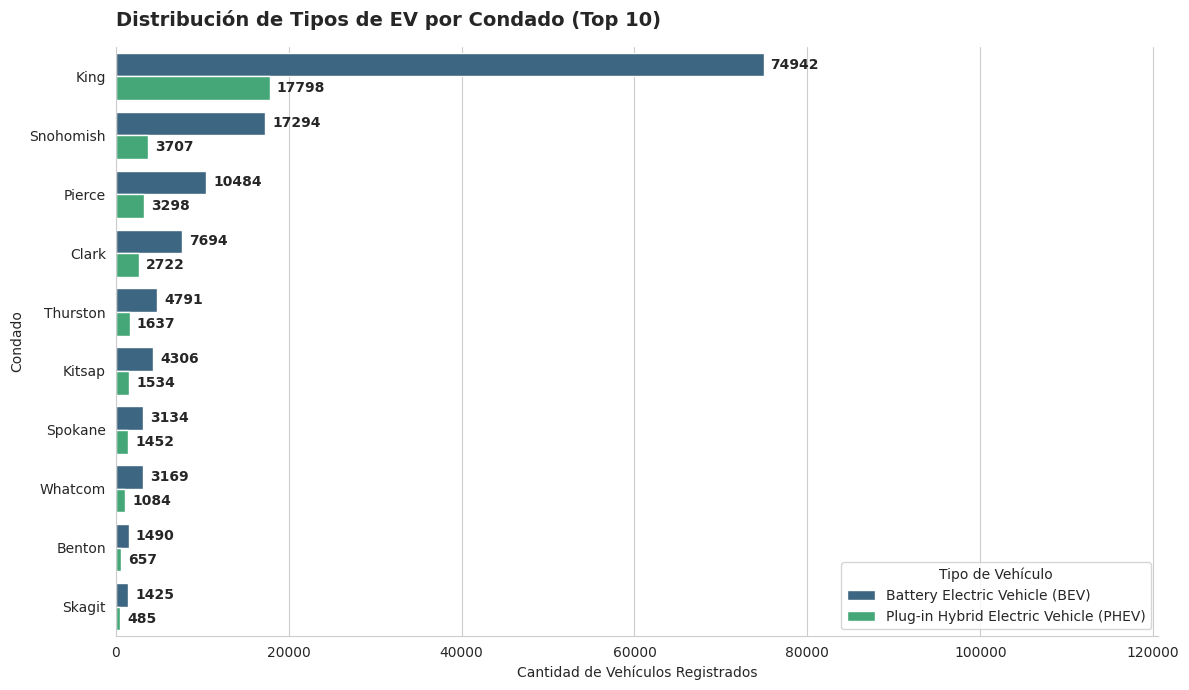

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 1. Obtenemos los 10 condados con más registros
top_condados = df_limpio['County'].value_counts().head(10).index
df_top_condados = df_limpio[df_limpio['County'].isin(top_condados)]

# 2. Graficamos agrupando por 'Electric Vehicle Type'
ax = sns.countplot(
    data=df_top_condados,
    y='County',
    hue='Electric Vehicle Type',
    order=top_condados,
    palette='viridis'
)

# 3. Ciclo para poner las cantidades exactas al final de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width)}',
            (width, p.get_y() + p.get_height() / 2),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(5, 0), textcoords='offset points'
        )

plt.title('Distribución de Tipos de EV por Condado (Top 10)', loc='left', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Vehículos Registrados')
plt.ylabel('Condado')
plt.legend(title='Tipo de Vehículo', loc='lower right')

# Ajuste de margen derecho para que los números no se corten
plt.xlim(0, df_top_condados['County'].value_counts().max() * 1.3)

sns.despine()
plt.tight_layout()
plt.show()

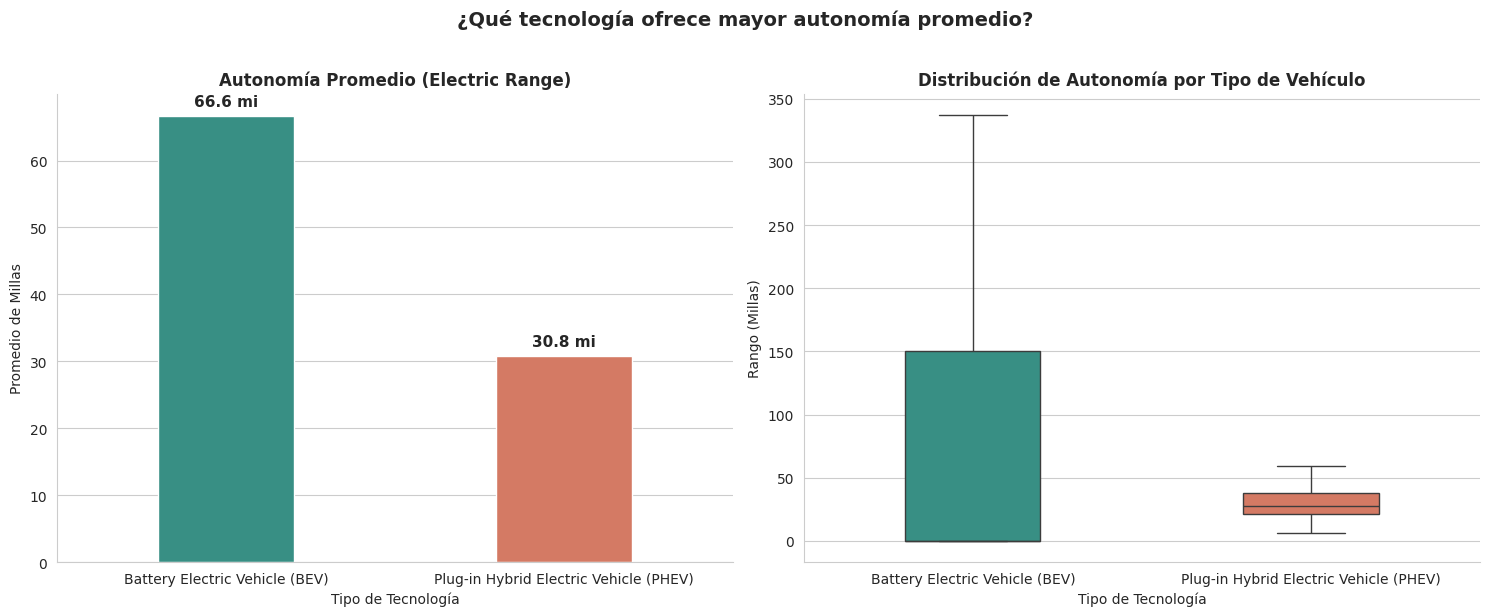

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos una copia y definimos colores para los tipos de vehículos
df_plot = df_limpio.copy()
color_bev = "#2A9D8F"  # Verde azulado (BEV)
color_phev = "#E76F51" # Coral (PHEV)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_style("whitegrid")

# 2. Barplot: Autonomía promedio por tipo de vehículo
sns.barplot(
    ax=axes[0],
    data=df_plot,
    x='Electric Vehicle Type',
    y='Electric Range',
    estimator='mean',
    errorbar=None,
    hue='Electric Vehicle Type',
    legend=False,
    palette={'Battery Electric Vehicle (BEV)': color_bev, 'Plug-in Hybrid Electric Vehicle (PHEV)': color_phev},
    width=0.4
)
axes[0].set_title('Autonomía Promedio (Electric Range)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo de Tecnología')
axes[0].set_ylabel('Promedio de Millas')

# Anotaciones de valor en las barras
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f'{round(height, 1)} mi',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            xytext=(0, 5), textcoords='offset points'
        )

# 3. Boxplot: Distribución y Cuartiles de la autonomía
sns.boxplot(
    ax=axes[1],
    data=df_plot,
    x='Electric Vehicle Type',
    y='Electric Range',
    hue='Electric Vehicle Type',
    legend=False,
    palette={'Battery Electric Vehicle (BEV)': color_bev, 'Plug-in Hybrid Electric Vehicle (PHEV)': color_phev},
    width=0.4,
    showfliers=False # Limpiamos los outliers para ver mejor la distribución central
)
axes[1].set_title('Distribución de Autonomía por Tipo de Vehículo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipo de Tecnología')
axes[1].set_ylabel('Rango (Millas)')

plt.suptitle('¿Qué tecnología ofrece mayor autonomía promedio?', fontsize=14, fontweight='bold', y=1.02)

sns.despine()
plt.tight_layout()
plt.show()

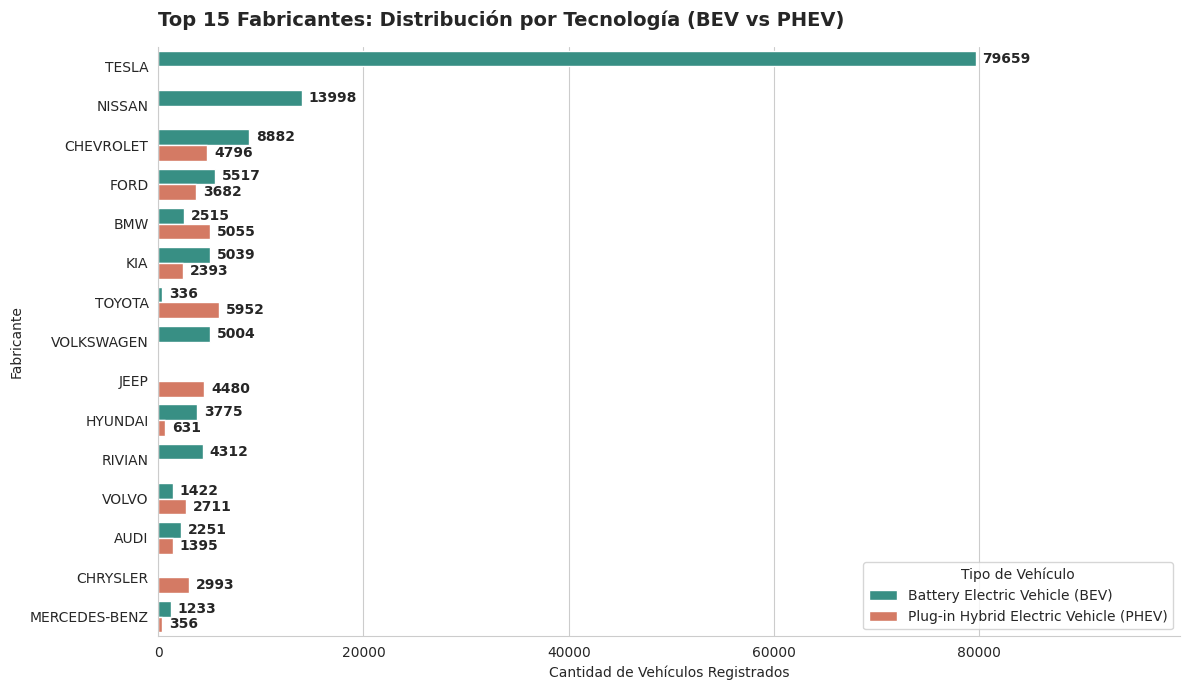

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 1. Filtramos marcas relevantes (Top 15 fabricantes)
top_marcas = df_limpio['Make'].value_counts().head(15).index
df_top_marcas = df_limpio[df_limpio['Make'].isin(top_marcas)]

# 2. Definimos colores consistentes para los tipos de vehículos
palette_ev = {'Battery Electric Vehicle (BEV)': '#2A9D8F', 'Plug-in Hybrid Electric Vehicle (PHEV)': '#E76F51'}

# 3. Graficamos agrupando por el tipo de tecnología
ax = sns.countplot(
    data=df_top_marcas,
    y='Make',
    hue='Electric Vehicle Type',
    order=top_marcas,
    palette=palette_ev
)

# 4. Anotaciones de cantidad
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width)}',
            (width, p.get_y() + p.get_height() / 2),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(5, 0), textcoords='offset points'
        )

plt.title('Top 15 Fabricantes: Distribución por Tecnología (BEV vs PHEV)',
          loc='left', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Vehículos Registrados')
plt.ylabel('Fabricante')
plt.legend(title='Tipo de Vehículo', loc='lower right')

# Ajuste de margen
plt.xlim(0, df_top_marcas['Make'].value_counts().max() * 1.25)

sns.despine()
plt.tight_layout()
plt.show()

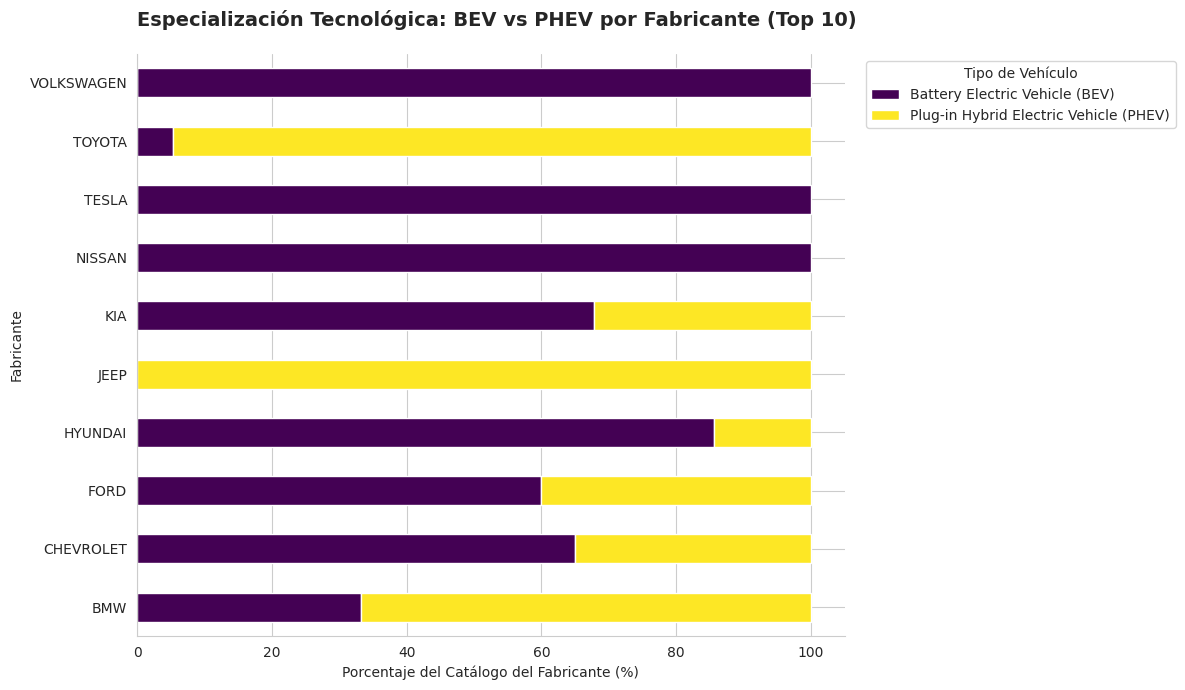

In [84]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Filtramos los 10 fabricantes con más registros
top_marcas = df_limpio['Make'].value_counts().head(10).index
df_top_marcas = df_limpio[df_limpio['Make'].isin(top_marcas)]

# 2. Creamos una tabla cruzada (Crosstab) normalizada para ver el porcentaje (%)
# Esto nos permite ver la composición de tecnología por fabricante
tabla_marca_tipo = pd.crosstab(
    df_top_marcas['Make'],
    df_top_marcas['Electric Vehicle Type'],
    normalize='index'
) * 100

# 3. Graficamos la barra apilada horizontal
ax = tabla_marca_tipo.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 7),
    cmap='viridis',
    edgecolor='white',
    linewidth=1
)

plt.title('Especialización Tecnológica: BEV vs PHEV por Fabricante (Top 10)',
          loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Porcentaje del Catálogo del Fabricante (%)')
plt.ylabel('Fabricante')

# Colocamos la leyenda fuera para que no tape los datos
plt.legend(title='Tipo de Vehículo', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

#Modelo

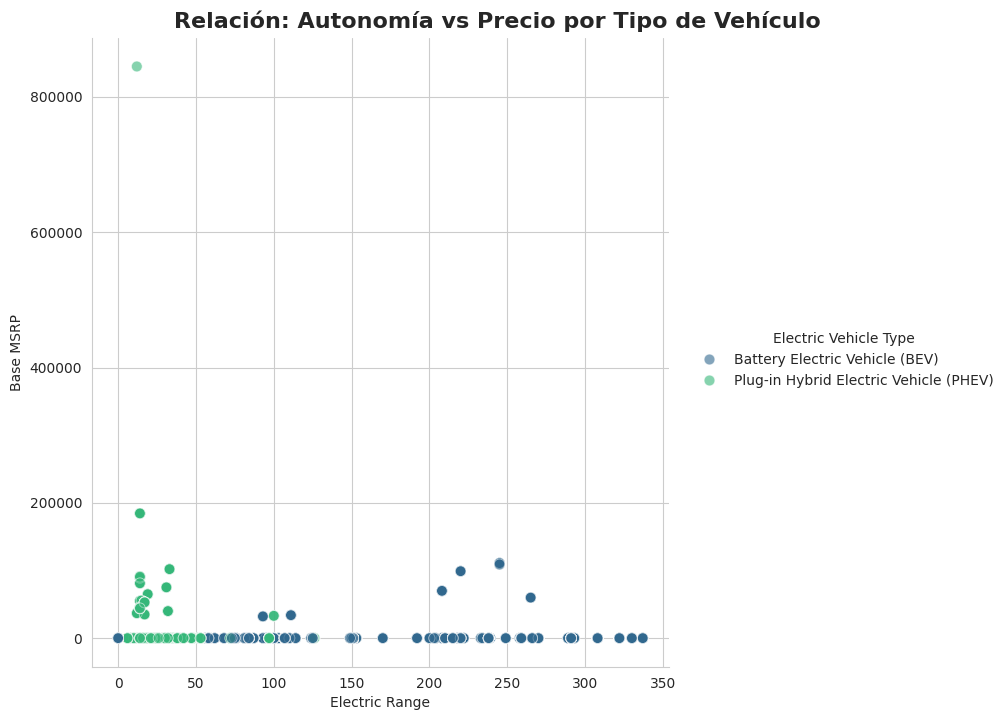

In [85]:

sns.set_style("whitegrid")

sns.pairplot(
    data=df_limpio,
    x_vars=['Electric Range'],
    y_vars=['Base MSRP'],
    hue='Electric Vehicle Type',
    palette='viridis',
    height=7,
    plot_kws={'s': 60, 'alpha': 0.6}
)

plt.suptitle('Relación: Autonomía vs Precio por Tipo de Vehículo', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [89]:
df_limpio.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [107]:

columnas_predictoras = ['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District']

x = df_limpio[columnas_predictoras].values
x

array([[2.020e+03, 2.910e+02, 0.000e+00, 3.700e+01],
       [2.023e+03, 0.000e+00, 0.000e+00, 1.000e+00],
       [2.019e+03, 2.700e+02, 0.000e+00, 3.600e+01],
       ...,
       [2.021e+03, 0.000e+00, 0.000e+00, 1.300e+01],
       [2.021e+03, 0.000e+00, 0.000e+00, 5.000e+00],
       [2.021e+03, 0.000e+00, 0.000e+00, 2.700e+01]])

In [108]:
y = df.iloc[:, 8].values
y

['Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)', ..., 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)']
Length: 177866
Categories (2, object): ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)']

In [109]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42)

In [110]:
#Conjunto de prueba
print(x_test)
len(x_test)

[[2.019e+03 2.200e+02 0.000e+00 4.300e+01]
 [2.016e+03 6.800e+01 0.000e+00 4.200e+01]
 [2.023e+03 0.000e+00 0.000e+00 1.000e+00]
 ...
 [2.021e+03 0.000e+00 0.000e+00 4.500e+01]
 [2.022e+03 0.000e+00 0.000e+00 3.400e+01]
 [2.020e+03 2.590e+02 0.000e+00 2.200e+01]]


35574

In [111]:
import math
math.sqrt(len(x_train))

377.2161184254989

In [112]:
from sklearn.preprocessing import  MinMaxScaler
scaler = MinMaxScaler(feature_range =(0,1))
scaler.fit(x_train)

MinMaxScaler()

In [113]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[0.81481481, 0.65281899, 0.        , 0.875     ],
       [0.7037037 , 0.20178042, 0.        , 0.85416667],
       [0.96296296, 0.        , 0.        , 0.        ],
       ...,
       [0.88888889, 0.        , 0.        , 0.91666667],
       [0.92592593, 0.        , 0.        , 0.6875    ],
       [0.85185185, 0.76854599, 0.        , 0.4375    ]])

In [114]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

In [115]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 377)
classifier.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=377)

In [116]:
y_pred = classifier.predict(x_test)
y_pred

array(['Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)',
       'Battery Electric Vehicle (BEV)', ...,
       'Battery Electric Vehicle (BEV)', 'Battery Electric Vehicle (BEV)',
       'Battery Electric Vehicle (BEV)'], dtype=object)

In [117]:
df['Electric Vehicle Type'].unique()

['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)']
Categories (2, object): ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)']

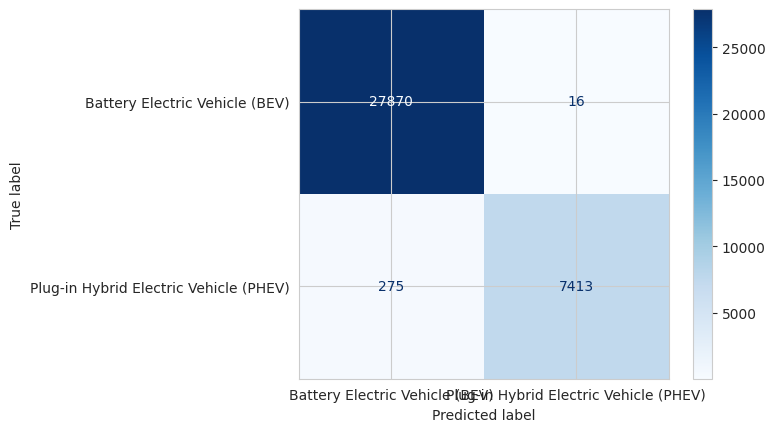

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['Battery Electric Vehicle (BEV)','Plug-in Hybrid Electric Vehicle (PHEV)']
normalize= None
ConfusionMatrixDisplay.from_estimator(
    classifier,
    x_test,
    y_test,
    display_labels = class_names,
    cmap= plt.cm.Blues,
    normalize = normalize, #se utiliza en dado caso de que el set de prueba tuviera una mayor de datos que el set de entrenamiento que no sea 80 - 20 clasico,
)

In [119]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       0.99      1.00      0.99     27886
Plug-in Hybrid Electric Vehicle (PHEV)       1.00      0.96      0.98      7688

                              accuracy                           0.99     35574
                             macro avg       0.99      0.98      0.99     35574
                          weighted avg       0.99      0.99      0.99     35574



Tras implementar un modelo de clasificación basado en K-Vecinos más cercanos (KNN), se logró una precisión global del 99%. La matriz de confusión demuestra una alta capacidad de discriminación entre vehículos eléctricos puros (BEV) e híbridos enchufables (PHEV), con una tasa de error insignificante. Este alto rendimiento confirma que las variables de autonomía, año de modelo y precio son indicadores fundamentales para la segmentación tecnológica del mercado automotriz en el Estado de Washington.

In [120]:
error = []

for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(x_train,y_train)
    pred_i= knn.predict(x_test)
    error.append(np.mean(pred_i !=y_test))

error

[np.float64(0.0010963062911114858),
 np.float64(0.0012649687974363299),
 np.float64(0.0015179625569235959),
 np.float64(0.0016022938100860179),
 np.float64(0.0021645021645021645),
 np.float64(0.0024174959239894305),
 np.float64(0.0023612750885478157),
 np.float64(0.0023893855062686233),
 np.float64(0.0025018271771518525),
 np.float64(0.0026142688480350817),
 np.float64(0.002726710518918311),
 np.float64(0.0030078146961263845),
 np.float64(0.0030359251138471917),
 np.float64(0.0031764772024512286),
 np.float64(0.0032889188733344578),
 np.float64(0.003485691797380109),
 np.float64(0.0035419126328217238),
 np.float64(0.003963568898633834),
 np.float64(0.003991679316354641),
 np.float64(0.004272783493562715),
 np.float64(0.004272783493562715),
 np.float64(0.004919323101141283),
 np.float64(0.004891212683420475),
 np.float64(0.005172316860628549),
 np.float64(0.005200427278349356),
 np.float64(0.005425310620115815),
 np.float64(0.005453421037836622),
 np.float64(0.00548153145555743),
 np.fl

(0.0, 0.2)

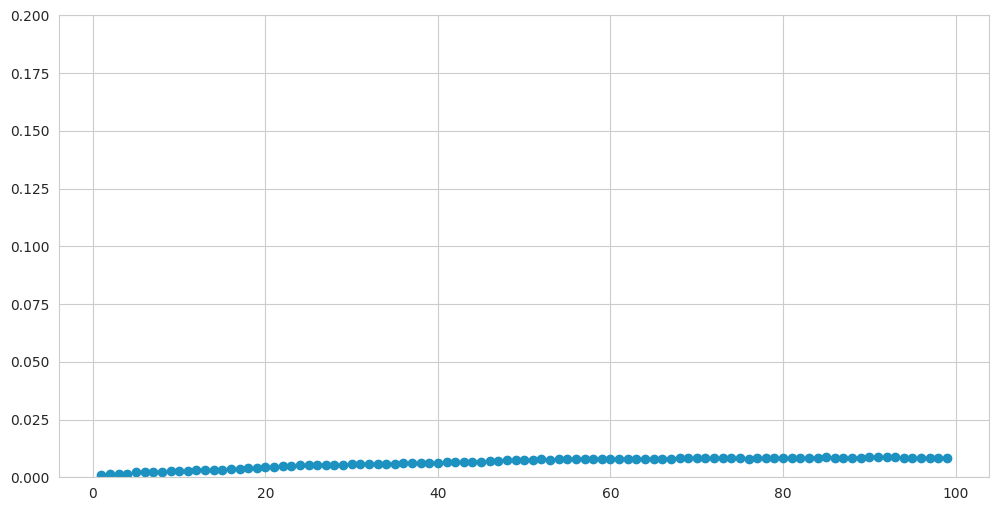

In [121]:
plt.figure(figsize=(12,6))
plt.plot(range(1,100), error, color = '#1d91c0', linestyle = 'dashed', marker= 'o')
plt.ylim(0,0.2)

# Conclusión

El mercado automotriz en Washington ha superado la fase de adopción temprana. La evidencia sugiere que la competitividad actual no depende del volumen, sino de la precisión tecnológica. Las empresas que logren equilibrar la autonomía (rango) con una segmentación geográfica precisa, utilizando modelos predictivos para alinear su oferta con el perfil técnico del consumidor, dominarán la siguiente etapa de la transición eléctrica.